# 01 — Exploratory Data Analysis

**Project**: Store Sales Time-Series Forecasting (Corporación Favorita)  
**Goal**: Understand the structure, patterns, and anomalies in the raw data before any feature engineering or modelling.  
**Metric**: RMSLE — Root Mean Squared Logarithmic Error.

All data is loaded via `src/data/loader.py`; no logic lives inline in this notebook.

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

# Make src/ importable regardless of where Jupyter is launched from
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.loader import load_raw_data

# ── aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (14, 4)

PALETTE = sns.color_palette("muted")
ACCENT  = PALETTE[0]

In [3]:
data = load_raw_data()

train        = data["train"]
test         = data["test"]
stores       = data["stores"]
oil          = data["oil"]
holidays     = data["holidays"]
transactions = data["transactions"]


──────────────────────────────────────────────────
  TRAIN  |  shape: (3000888, 6)
──────────────────────────────────────────────────
id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64

──────────────────────────────────────────────────
  TEST  |  shape: (28512, 5)
──────────────────────────────────────────────────
id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
onpromotion             int64

──────────────────────────────────────────────────
  STORES  |  shape: (54, 5)
──────────────────────────────────────────────────
store_nbr     int64
city         object
state        object
type         object
cluster       int64

──────────────────────────────────────────────────
  OIL  |  shape: (1218, 2)
──────────────────────────────────────────────────
date          datetime64[ns]
dcoilwtico   

---
## 1 · Sales Overview — Trend & Seasonality

Total daily sales aggregated across all stores and product families gives the clearest
view of the macro signal we are trying to model.  
Key questions:
- Is there a long-term upward or downward trend?
- Is there strong weekly / annual seasonality?
- Are there obvious one-off spikes or gaps that might indicate data issues or real events (e.g. earthquakes, strikes)?

Understanding these patterns dictates which lag windows and calendar features to build.

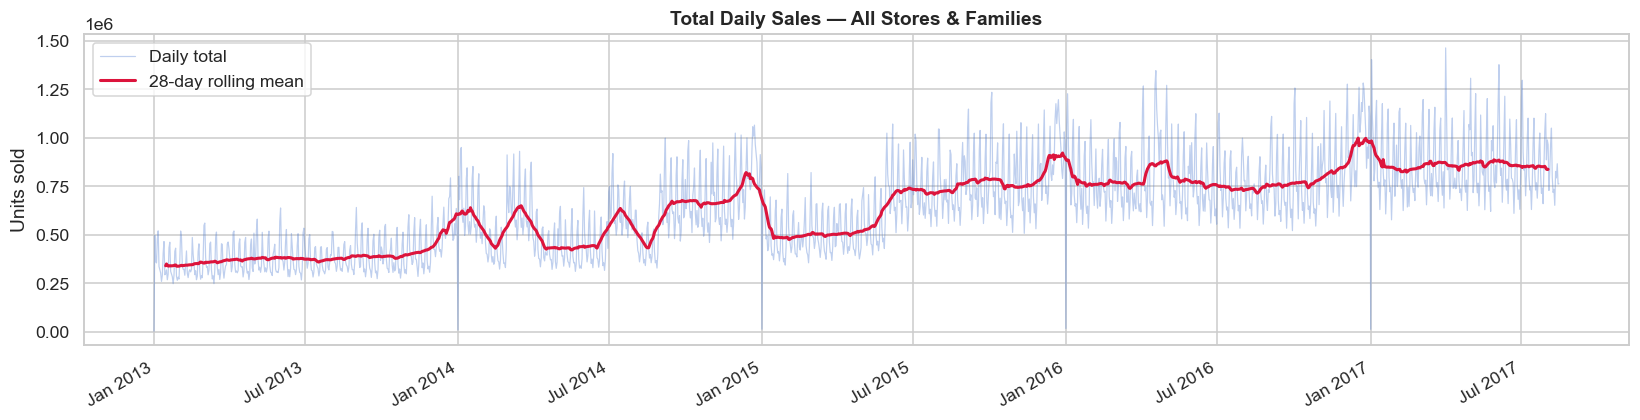

In [4]:
daily_sales = (
    train.groupby("date", as_index=False)["sales"]
    .sum()
    .rename(columns={"sales": "total_sales"})
)

daily_sales["rolling_28d"] = daily_sales["total_sales"].rolling(28, center=True).mean()

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(daily_sales["date"], daily_sales["total_sales"],
        alpha=0.35, linewidth=0.8, color=ACCENT, label="Daily total")
ax.plot(daily_sales["date"], daily_sales["rolling_28d"],
        linewidth=2, color="crimson", label="28-day rolling mean")
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.set_title("Total Daily Sales — All Stores & Families", fontweight="bold")
ax.set_ylabel("Units sold")
ax.legend()
plt.tight_layout()
plt.show()

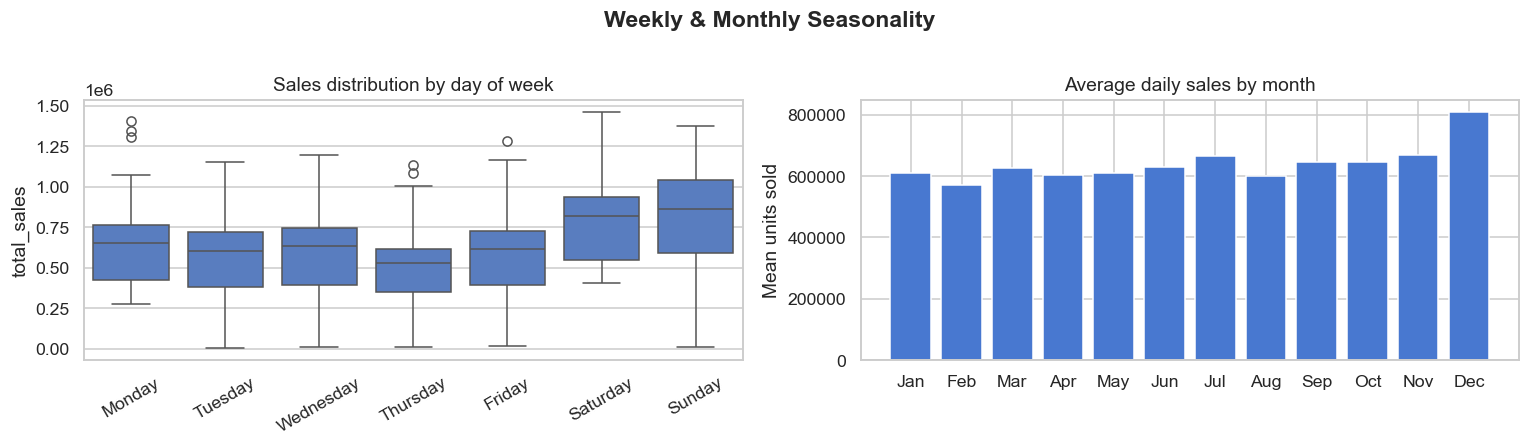

In [5]:
# ── Weekly seasonality ───────────────────────────────────────────────────────
daily_sales["dayofweek"] = daily_sales["date"].dt.day_name()
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(
    data=daily_sales, x="dayofweek", y="total_sales",
    order=dow_order, ax=axes[0], color=ACCENT
)
axes[0].set_title("Sales distribution by day of week")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

# ── Monthly seasonality ──────────────────────────────────────────────────────
daily_sales["month"] = daily_sales["date"].dt.month
monthly_mean = daily_sales.groupby("month")["total_sales"].mean()

axes[1].bar(monthly_mean.index, monthly_mean.values, color=ACCENT, edgecolor="white")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(
    ["Jan","Feb","Mar","Apr","May","Jun",
     "Jul","Aug","Sep","Oct","Nov","Dec"]
)
axes[1].set_title("Average daily sales by month")
axes[1].set_ylabel("Mean units sold")

plt.suptitle("Weekly & Monthly Seasonality", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 2 · Store Analysis — Type & Cluster

Corporación Favorita operates stores of different **types** (A–E) and groups them into
**clusters** (1–17) based on similar characteristics.  
Sales volumes can differ dramatically between store types, so the model needs these as
categorical features (or separate models per type).  
This section checks:
- Which store types generate the most revenue?
- How homogeneous are clusters? High within-cluster variance means cluster alone is a weak signal.

C:\Users\oscar\AppData\Local\Temp\ipykernel_5652\984858947.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


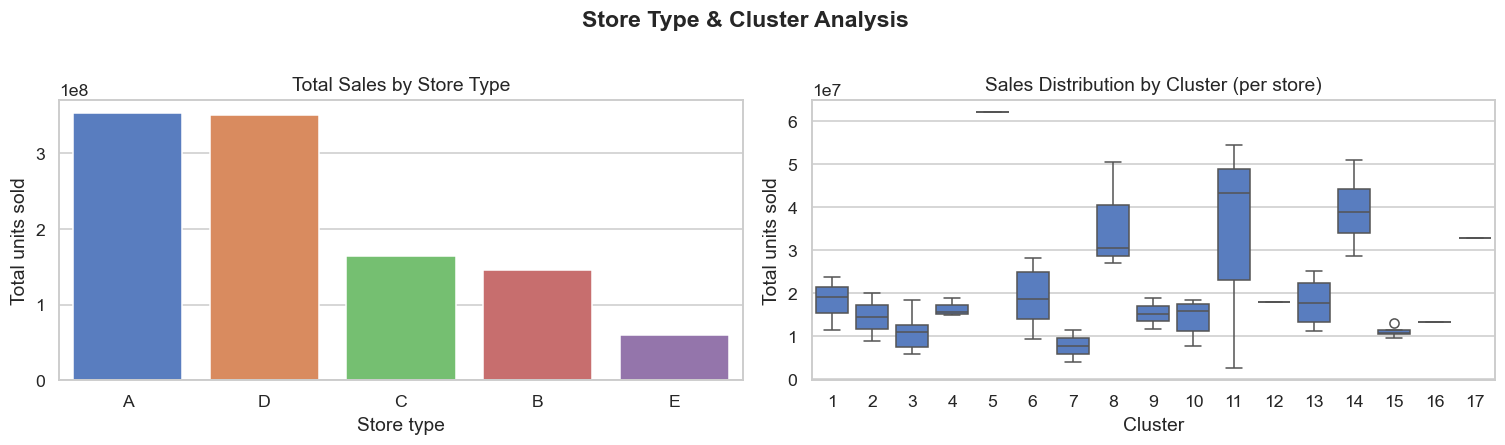


Store count per type:
type
D    18
C    15
A     9
B     8
E     4

Store count per cluster:
cluster
1     3
2     2
3     7
4     3
5     1
6     6
7     2
8     3
9     2
10    6
11    3
12    1
13    4
14    4
15    5
16    1
17    1


In [6]:
train_stores = train.merge(stores, on="store_nbr", how="left")

type_sales = (
    train_stores.groupby("type", as_index=False)["sales"]
    .sum()
    .sort_values("sales", ascending=False)
)

cluster_sales = (
    train_stores.groupby(["store_nbr", "cluster"], as_index=False)["sales"]
    .sum()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(
    data=type_sales, x="type", y="sales",
    palette="muted", ax=axes[0]
)
axes[0].set_title("Total Sales by Store Type")
axes[0].set_ylabel("Total units sold")
axes[0].set_xlabel("Store type")

sns.boxplot(
    data=cluster_sales, x="cluster", y="sales",
    color=ACCENT, ax=axes[1]
)
axes[1].set_title("Sales Distribution by Cluster (per store)")
axes[1].set_ylabel("Total units sold")
axes[1].set_xlabel("Cluster")

plt.suptitle("Store Type & Cluster Analysis", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\nStore count per type:")
print(stores["type"].value_counts().to_string())
print("\nStore count per cluster:")
print(stores["cluster"].value_counts().sort_index().to_string())

---
## 3 · Product Families — Volume & Distribution

The dataset contains **33 product families** (GROCERY I, BEVERAGES, PRODUCE, …).  
Families with near-zero sales most days are effectively sparse series — they may need
dedicated handling (e.g. zero-inflated models or a separate clip floor).  
Understanding the sales magnitude per family is also critical because RMSLE penalises
relative errors: a 10-unit miss on a 20-unit family is catastrophic, but negligible on
a 50 000-unit family.

C:\Users\oscar\AppData\Local\Temp\ipykernel_5652\1675598124.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, y="family", x="sales", palette="Blues_r", ax=axes[0])
C:\Users\oscar\AppData\Local\Temp\ipykernel_5652\1675598124.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot10, y="family", x="sales", palette="Reds_r", ax=axes[1])


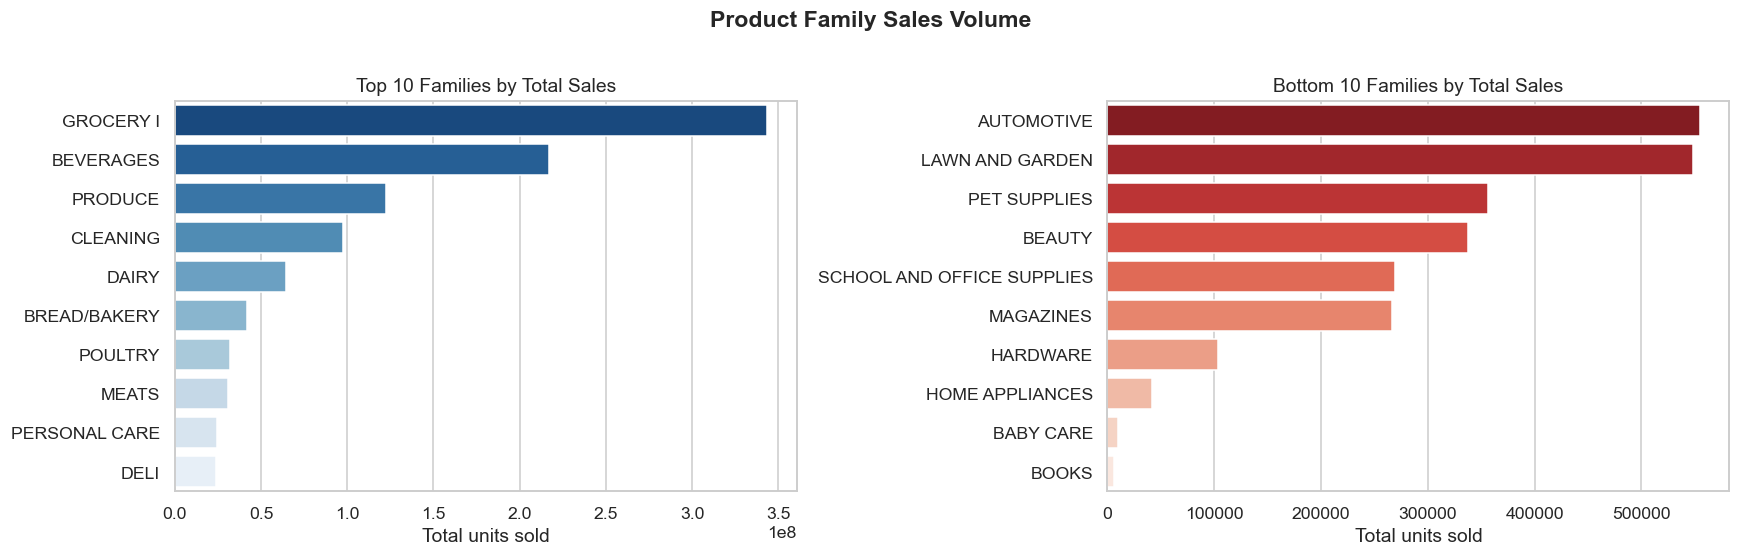

In [7]:
family_sales = (
    train.groupby("family", as_index=False)["sales"]
    .sum()
    .sort_values("sales", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 10
top10 = family_sales.head(10)
sns.barplot(data=top10, y="family", x="sales", palette="Blues_r", ax=axes[0])
axes[0].set_title("Top 10 Families by Total Sales")
axes[0].set_xlabel("Total units sold")
axes[0].set_ylabel("")

# Bottom 10
bot10 = family_sales.tail(10)
sns.barplot(data=bot10, y="family", x="sales", palette="Reds_r", ax=axes[1])
axes[1].set_title("Bottom 10 Families by Total Sales")
axes[1].set_xlabel("Total units sold")
axes[1].set_ylabel("")

plt.suptitle("Product Family Sales Volume", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

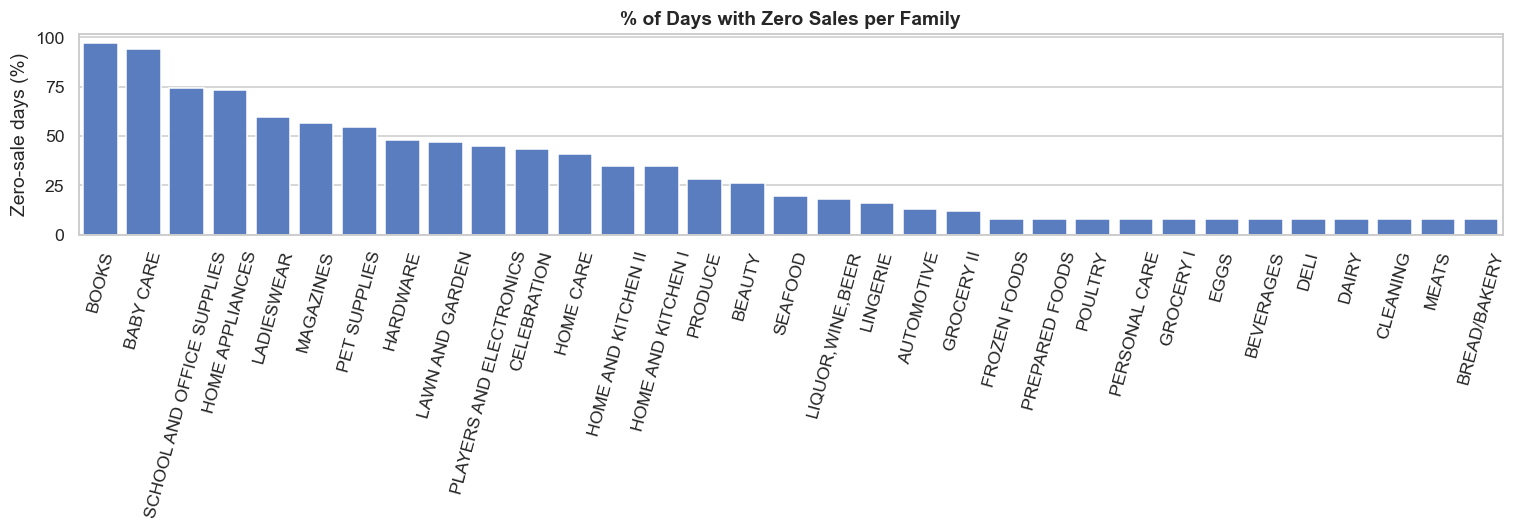

Families with >50 % zero-sales days:
                    family  pct_zero_days
                     BOOKS      96.955001
                 BABY CARE      94.131037
SCHOOL AND OFFICE SUPPLIES      74.082871
           HOME APPLIANCES      73.517639
                LADIESWEAR      59.846485
                 MAGAZINES      56.538665
              PET SUPPLIES      54.615334


In [8]:
# ── Zero-sales prevalence per family ────────────────────────────────────────
zero_pct = (
    train.assign(is_zero=train["sales"] == 0)
    .groupby("family")["is_zero"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"is_zero": "pct_zero_days"})
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=zero_pct, x="family", y="pct_zero_days", color=ACCENT, ax=ax)
ax.set_title("% of Days with Zero Sales per Family", fontweight="bold")
ax.set_ylabel("Zero-sale days (%)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()

print("Families with >50 % zero-sales days:")
print(zero_pct.query("pct_zero_days > 50")[["family", "pct_zero_days"]].to_string(index=False))

---
## 4 · Promotions Impact

`onpromotion` counts the number of items in a store/family combination that are
actively promoted on a given day.  
Promotions are one of the **strongest predictors** of short-term sales lifts in retail
forecasting. This section quantifies the average lift and checks whether the effect
differs across families, informing whether promotion lag/lead features are worth adding.

In [9]:
train_promo = train.copy()
train_promo["has_promo"] = train_promo["onpromotion"] > 0

promo_summary = (
    train_promo.groupby("has_promo")["sales"]
    .agg(["mean", "median", "std"])
    .rename(index={False: "No promo", True: "With promo"})
)
print("Sales statistics — promo vs no-promo:")
print(promo_summary.round(2))

lift = (
    promo_summary.loc["With promo", "mean"]
    / promo_summary.loc["No promo", "mean"]
    - 1
) * 100
print(f"\nAverage sales lift from promotion: {lift:.1f} %")

Sales statistics — promo vs no-promo:
               mean  median      std
has_promo                           
No promo     158.25     3.0   614.89
With promo  1137.69   373.0  1928.59

Average sales lift from promotion: 618.9 %


C:\Users\oscar\AppData\Local\Temp\ipykernel_5652\677179357.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=family_promo, y="family", x="lift_pct", palette="Greens_r", ax=axes[1])


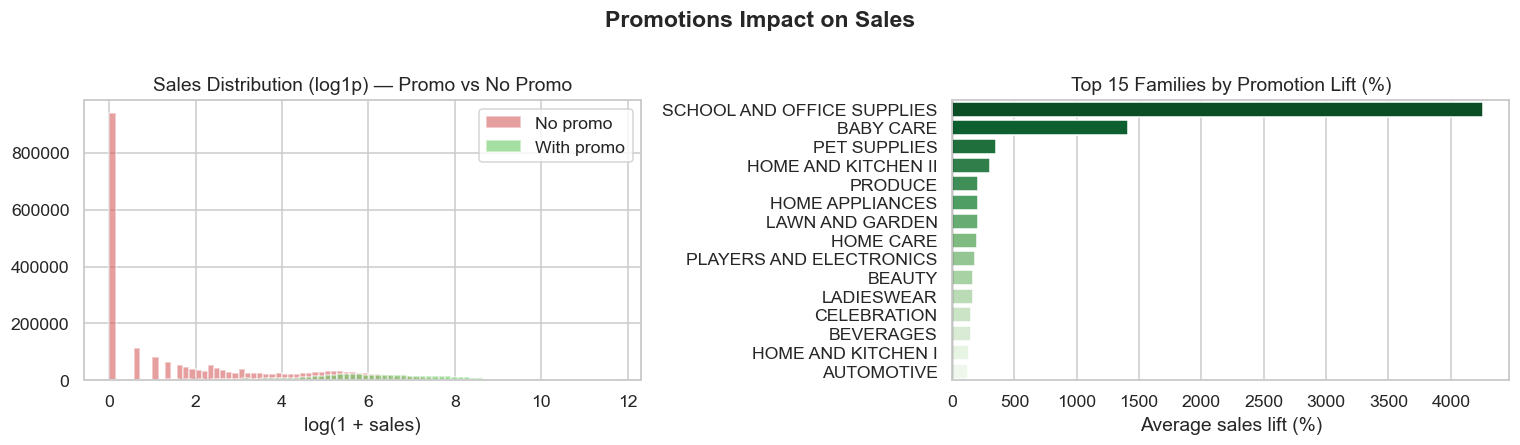

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution comparison (log scale for readability)
for flag, label, color in [(False, "No promo", PALETTE[3]), (True, "With promo", PALETTE[2])]:
    subset = train_promo.loc[train_promo["has_promo"] == flag, "sales"]
    axes[0].hist(
        np.log1p(subset), bins=80, alpha=0.6, label=label, color=color
    )
axes[0].set_title("Sales Distribution (log1p) — Promo vs No Promo")
axes[0].set_xlabel("log(1 + sales)")
axes[0].legend()

# Per-family lift
family_promo = (
    train_promo.groupby(["family", "has_promo"])["sales"]
    .mean()
    .unstack()
    .rename(columns={False: "no_promo", True: "with_promo"})
    .assign(lift_pct=lambda d: (d["with_promo"] / d["no_promo"] - 1) * 100)
    .sort_values("lift_pct", ascending=False)
    .head(15)
    .reset_index()
)
sns.barplot(data=family_promo, y="family", x="lift_pct", palette="Greens_r", ax=axes[1])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Top 15 Families by Promotion Lift (%)")
axes[1].set_xlabel("Average sales lift (%)")
axes[1].set_ylabel("")

plt.suptitle("Promotions Impact on Sales", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 5 · Holidays Effect

Ecuador has a rich holiday calendar — national, regional, and local observances —
plus bridge days (`transferred` holidays) that shift demand patterns.  
Holidays can cause both **surges** (pre-holiday shopping) and **dips** (store closures).
This section measures the average effect and distinguishes between national and local
holidays, since a local holiday only affects stores in that region.

In [11]:
# Keep only actual holidays (not bridge/transfer meta-rows)
nat_holidays = (
    holidays
    .query("type != 'Work Day' and transferred == False")
    [["date", "type", "locale"]]
    .drop_duplicates("date")
)

daily_sales_hol = daily_sales[["date", "total_sales"]].merge(
    nat_holidays, on="date", how="left"
)
daily_sales_hol["is_holiday"] = daily_sales_hol["type"].notna()
daily_sales_hol["holiday_locale"] = daily_sales_hol["locale"].fillna("None")

hol_summary = (
    daily_sales_hol.groupby("is_holiday")["total_sales"]
    .agg(["mean", "median"])
    .rename(index={False: "Regular day", True: "Holiday"})
)
print("Mean & median total daily sales:")
print(hol_summary.round(0))

Mean & median total daily sales:
                 mean    median
is_holiday                     
Regular day  627011.0  624797.0
Holiday      701313.0  689746.0


C:\Users\oscar\AppData\Local\Temp\ipykernel_5652\4116927063.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\oscar\AppData\Local\Temp\ipykernel_5652\4116927063.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Regular day", "Holiday"])
C:\Users\oscar\AppData\Local\Temp\ipykernel_5652\4116927063.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


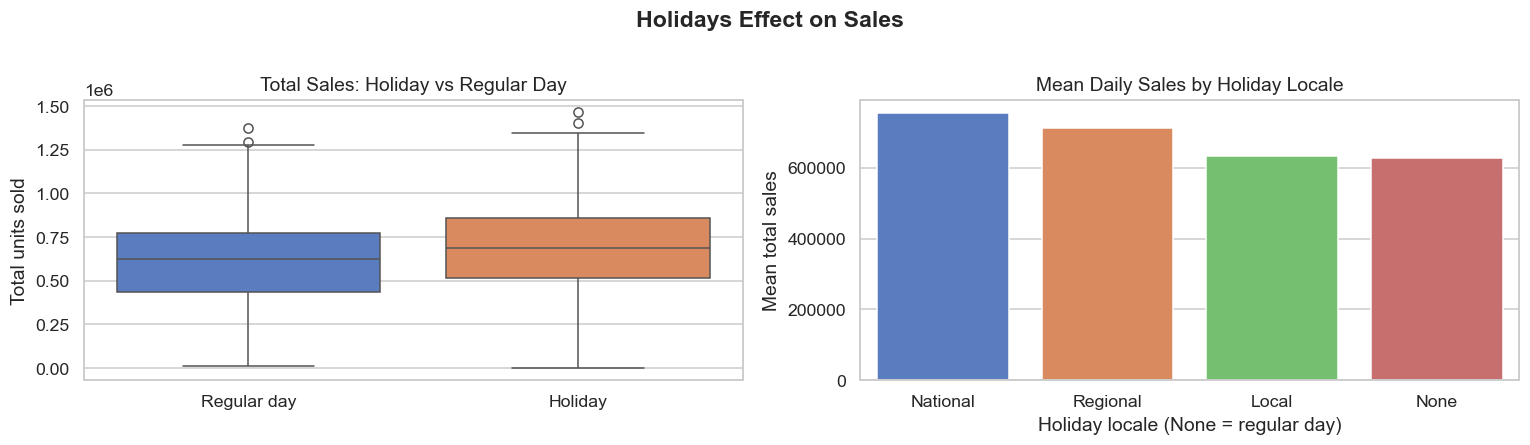

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Box plot: holiday vs regular
sns.boxplot(
    data=daily_sales_hol, x="is_holiday", y="total_sales",
    palette=[PALETTE[0], PALETTE[1]], ax=axes[0]
)
axes[0].set_xticklabels(["Regular day", "Holiday"])
axes[0].set_title("Total Sales: Holiday vs Regular Day")
axes[0].set_ylabel("Total units sold")
axes[0].set_xlabel("")

# Mean sales by locale
locale_means = (
    daily_sales_hol.groupby("holiday_locale")["total_sales"]
    .mean()
    .reset_index()
    .sort_values("total_sales", ascending=False)
)
sns.barplot(
    data=locale_means, x="holiday_locale", y="total_sales",
    palette="muted", ax=axes[1]
)
axes[1].set_title("Mean Daily Sales by Holiday Locale")
axes[1].set_xlabel("Holiday locale (None = regular day)")
axes[1].set_ylabel("Mean total sales")

plt.suptitle("Holidays Effect on Sales", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 6 · Oil Price Correlation

Ecuador's economy is heavily dependent on oil exports, so the **Brent crude price**
(`dcoilwtico`) acts as a macroeconomic proxy for consumer purchasing power.  
A sustained drop in oil prices tends to suppress consumer spending, affecting sales
across all categories with varying lags.  
Key questions:
- Is there a contemporaneous or lagged correlation between oil price and total sales?
- Is the relationship stable over time, or does it break at certain price thresholds?

In [13]:
oil_sales = daily_sales[["date", "total_sales"]].merge(oil, on="date", how="left")

# Pearson correlation for multiple lags
lag_corrs = {
    lag: oil_sales["total_sales"].corr(
        oil_sales["dcoilwtico"].shift(lag)
    )
    for lag in range(0, 29, 7)
}

print("Pearson r between oil price (lagged) and total sales:")
for lag, r in lag_corrs.items():
    print(f"  lag {lag:2d}d → {r:+.4f}")

Pearson r between oil price (lagged) and total sales:
  lag  0d → -0.6903
  lag  7d → -0.6855
  lag 14d → -0.6782
  lag 21d → -0.6705
  lag 28d → -0.6627


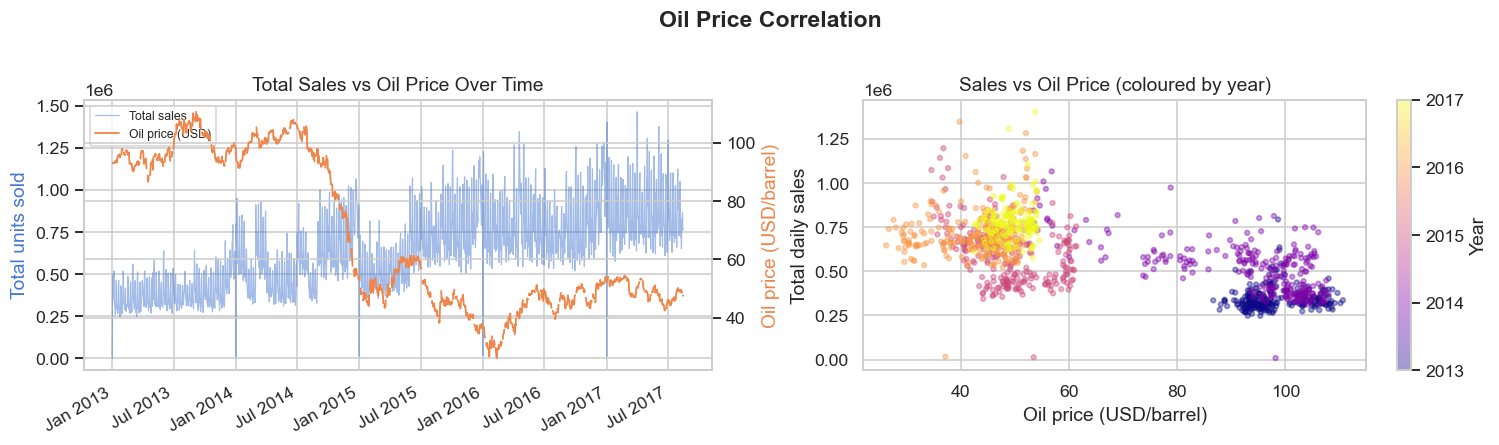

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Dual-axis time series
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(oil_sales["date"], oil_sales["total_sales"],
         alpha=0.5, color=PALETTE[0], linewidth=0.8, label="Total sales")
ax2.plot(oil_sales["date"], oil_sales["dcoilwtico"],
         color=PALETTE[1], linewidth=1.2, label="Oil price (USD)")
ax1.set_ylabel("Total units sold", color=PALETTE[0])
ax2.set_ylabel("Oil price (USD/barrel)", color=PALETTE[1])
ax1.set_title("Total Sales vs Oil Price Over Time")
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

# Scatter with colour-coded year
oil_sales_clean = oil_sales.dropna(subset=["dcoilwtico"])
oil_sales_clean = oil_sales_clean.assign(year=oil_sales_clean["date"].dt.year)
scatter = axes[1].scatter(
    oil_sales_clean["dcoilwtico"],
    oil_sales_clean["total_sales"],
    c=oil_sales_clean["year"],
    cmap="plasma", alpha=0.4, s=10
)
plt.colorbar(scatter, ax=axes[1], label="Year")
axes[1].set_xlabel("Oil price (USD/barrel)")
axes[1].set_ylabel("Total daily sales")
axes[1].set_title("Sales vs Oil Price (coloured by year)")

plt.suptitle("Oil Price Correlation", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 7 · Missing Values Report

Missing values must be handled explicitly before any model training.  
This section provides a complete audit across all six datasets so that the
preprocessing step in `src/data/preprocessor.py` can address each gap with the
right strategy (forward-fill, interpolation, indicator flag, or drop).

In [15]:
def missing_report(name: str, df: pd.DataFrame) -> pd.DataFrame:
    """Return a DataFrame summarising null counts and percentages."""
    null_counts = df.isnull().sum()
    report = pd.DataFrame({
        "dataset": name,
        "column": null_counts.index,
        "null_count": null_counts.values,
        "null_pct": (null_counts / len(df) * 100).round(2).values,
        "dtype": df.dtypes.values,
    })
    return report.query("null_count > 0")

named_datasets = {
    "train": train,
    "test": test,
    "stores": stores,
    "oil (post-ffill)": oil,
    "holidays": holidays,
    "transactions": transactions,
}

all_missing = pd.concat(
    [missing_report(name, df) for name, df in named_datasets.items()],
    ignore_index=True,
)

if all_missing.empty:
    print("No missing values found across all datasets after loading.")
else:
    print(f"Columns with nulls ({len(all_missing)} total):")
    print(all_missing.to_string(index=False))

Columns with nulls (1 total):
         dataset     column  null_count  null_pct   dtype
oil (post-ffill) dcoilwtico           1      0.08 float64


In [16]:
# ── Heatmap of null presence across train columns ────────────────────────────
sample_nulls = train.isnull().astype(int)
if sample_nulls.any().any():
    fig, ax = plt.subplots(figsize=(10, 3))
    sns.heatmap(
        sample_nulls.sample(5000, random_state=42).T,
        cbar=False, ax=ax, yticklabels=True, xticklabels=False
    )
    ax.set_title("Null Heatmap — train (random 5 k rows)", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("train has no missing values — heatmap skipped.")

# ── Oil: show remaining nulls before/after ffill ────────────────────────────
oil_raw = pd.read_csv(
    Path().resolve().parent / "data" / "raw" / "oil.csv",
    parse_dates=["date"],
)
print(f"\noil.csv — nulls BEFORE ffill : {oil_raw['dcoilwtico'].isnull().sum()}")
print(f"oil.csv — nulls AFTER  ffill : {oil['dcoilwtico'].isnull().sum()}")

train has no missing values — heatmap skipped.

oil.csv — nulls BEFORE ffill : 43
oil.csv — nulls AFTER  ffill : 1


---
## Summary of EDA Findings

| Finding | Modelling implication |
|---|---|
| Clear upward trend + strong weekly cycle | Lag features at t-7, t-14 are essential |
| December and end-of-month spikes | Month, day-of-month, and quincena calendar features needed |
| Store type A dominates revenue | Store type as categorical feature; consider per-type models |
| Several families >50 % zero-sale days | Zero-inflation handling or log1p transform |
| Promotion lift varies widely by family | `onpromotion` + family interaction features |
| Holidays generally suppress total sales | `is_holiday`, `locale_holiday`, and lead/lag features |
| Oil price weakly correlated, lagged ~7d | Include oil price with 7-day lag; monitor feature importance |
| Oil ffill resolves most oil nulls | One residual null at series start — safe to drop or backfill |